<a href="https://colab.research.google.com/github/Arif0000/GFG-21-Days-Live-class-task/blob/main/Task_17.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install torch torchvision matplotlib scikit-learn

In [2]:
import torch
import torchvision
import torchvision.transforms as transforms

import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics.pairwise import cosine_similarity

In [3]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

# Take only 20 samples
subset = torch.utils.data.Subset(dataset, list(range(20)))

loader = torch.utils.data.DataLoader(subset, batch_size=1, shuffle=False)

classes = dataset.classes

100%|██████████| 170M/170M [00:10<00:00, 16.4MB/s]


In [4]:
import torchvision.models as models

model = models.resnet18(pretrained=True)
model = torch.nn.Sequential(*list(model.children())[:-1])  # remove classifier
model.eval()

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 119MB/s]


Sequential(
  (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (4): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Con

In [5]:
embeddings = []
labels = []
images = []

with torch.no_grad():
    for img, label in loader:
        emb = model(img).squeeze().numpy()
        embeddings.append(emb)
        labels.append(label.item())
        images.append(img.squeeze().permute(1,2,0).numpy())

embeddings = np.array(embeddings)

In [6]:
def retrieve(query_img, top_k=3):
    with torch.no_grad():
        query_emb = model(query_img.unsqueeze(0)).squeeze().numpy()

    sims = cosine_similarity([query_emb], embeddings)[0]
    indices = sims.argsort()[-top_k:][::-1]

    return indices

In [7]:
def generate_response(indices):
    retrieved_labels = [classes[labels[i]] for i in indices]

    response = f"This image is similar to: {', '.join(retrieved_labels)}"

    return response

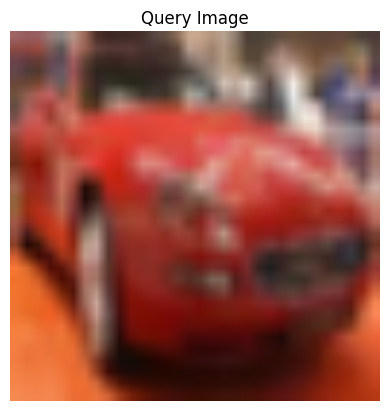

Retrieved Images:


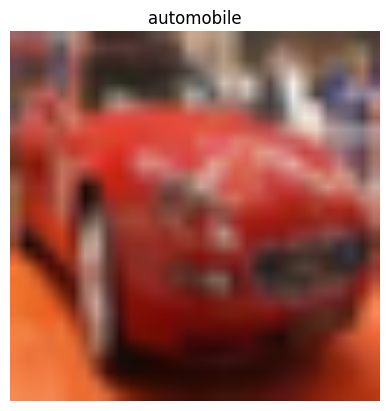

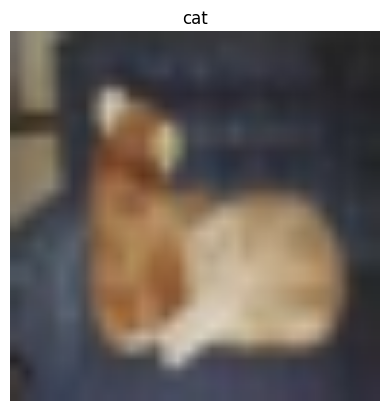

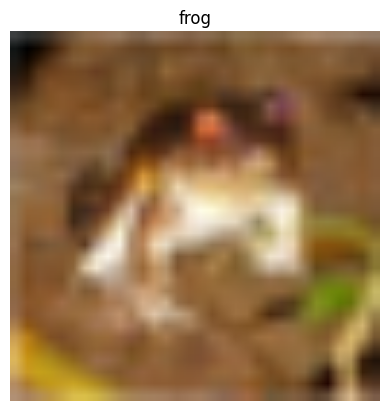

This image is similar to: automobile, cat, frog


In [8]:
# Take a query image
query_img, query_label = subset[5]

plt.imshow(query_img.permute(1,2,0))
plt.title("Query Image")
plt.axis('off')
plt.show()

indices = retrieve(query_img)

print("Retrieved Images:")
for i in indices:
    plt.imshow(images[i])
    plt.title(classes[labels[i]])
    plt.axis('off')
    plt.show()

print(generate_response(indices))